In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
def cargarDatos():

    # Carpeta donde están los archivos
    carpeta = "../estaciones"

    # Lista para guardar los DataFrames
    dfs = []

    # Recorrer todos los archivos de la carpeta
    for archivo in os.listdir(carpeta):
        if archivo.endswith(".csv") and archivo.startswith("est_"): # Filtrar archivos CSV que comienzan con "est_"
            ruta_completa = os.path.join(carpeta, archivo)
            df = pd.read_csv(ruta_completa)
            dfs.append(df)
            ncols = df.shape[1]
            print(f"Cargado: {archivo} con {ncols} columnas.")

    # Unir todos los DataFrames
    df_clima = pd.concat(dfs, ignore_index=True)

    print("Archivos unidos correctamente.")

    return df_clima

df_clima = cargarDatos()

Cargado: est_19.csv con 21 columnas.
Cargado: est_20.csv con 21 columnas.
Cargado: est_21.csv con 21 columnas.
Cargado: est_22.csv con 21 columnas.


C:\Users\Ismathrn\AppData\Local\Temp\ipykernel_9228\1121407733.py:13: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_completa)


Cargado: est_23.csv con 21 columnas.
Cargado: est_24.csv con 21 columnas.


C:\Users\Ismathrn\AppData\Local\Temp\ipykernel_9228\1121407733.py:13: DtypeWarning: Columns (2,3,4,7,8,9,10,12,13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_completa)


Cargado: est_25.csv con 21 columnas.


...

Cargado: est_28.csv con 21 columnas.
Cargado: est_29.csv con 21 columnas.


C:\Users\Ismathrn\AppData\Local\Temp\ipykernel_9228\1121407733.py:13: DtypeWarning: Columns (2,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_completa)


Cargado: est_30.csv con 22 columnas.


C:\Users\Ismathrn\AppData\Local\Temp\ipykernel_9228\1121407733.py:13: DtypeWarning: Columns (2,3,4,7,8,9,10,12,13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_completa)


Cargado: est_31.csv con 21 columnas.
Archivos unidos correctamente.


Encontramos un comportamiento importante en la carga de datos relacionado a los tipos de valores encontrados en la columnas, y columnas adicionales en las estaciones 27 y 30 por lo que vamos a proceder a realizar un analisis estadistico de las columnas y sus valores.

In [4]:
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407292 entries, 0 to 11407291
Data columns (total 22 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   fecha               object
 1   hora                object
 2   temperatura         object
 3   velocidad           object
 4   direccion           object
 5   direccion_rosa      object
 6   caudal              object
 7   presion             object
 8   humedad             object
 9   precipitacion       object
 10  precipitacion_real  object
 11  radiacion           object
 12  evapotranspiracion  object
 13  evapo_real          object
 14  nivel               object
 15  puerta_Abierta      bool  
 16  bateria_Baja        bool  
 17  solar_energia       bool  
 18  sensor_Activo       bool  
 19  observaciones       object
 20  estacion_sk         int64 
 21  estado_Alarma       object
dtypes: bool(4), int64(1), object(17)
memory usage: 1.6+ GB


In [5]:
columnas_estandar = [
    "fecha","hora","temperatura","velocidad","direccion","direccion_rosa",
    "caudal","presion","humedad","precipitacion","precipitacion_real",
    "radiacion","evapotranspiracion","evapo_real","nivel",
    "estado_Alarma",
    "puerta_Abierta","bateria_Baja","solar_energia","sensor_Activo",
    "observaciones","estacion_sk","timestamp"
]

# Asegurarse de que el DataFrame tenga las columnas y en el orden correcto
for col in columnas_estandar:
    if col not in df_clima.columns:
        df_clima[col] = pd.NA

df_clima = df_clima[columnas_estandar] # Asegura que el orden de las columnas sea exactamente el definido.

df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407292 entries, 0 to 11407291
Data columns (total 23 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   fecha               object
 1   hora                object
 2   temperatura         object
 3   velocidad           object
 4   direccion           object
 5   direccion_rosa      object
 6   caudal              object
 7   presion             object
 8   humedad             object
 9   precipitacion       object
 10  precipitacion_real  object
 11  radiacion           object
 12  evapotranspiracion  object
 13  evapo_real          object
 14  nivel               object
 15  estado_Alarma       object
 16  puerta_Abierta      bool  
 17  bateria_Baja        bool  
 18  solar_energia       bool  
 19  sensor_Activo       bool  
 20  observaciones       object
 21  estacion_sk         int64 
 22  timestamp           object
dtypes: bool(4), int64(1), object(18)
memory usage: 1.7+ GB


Aunque desde la concatenación ya se agrego la columna estado_Alarma, en integración de bases meteorológicas se recomienda definir un “esquema maestro” y crear columnas faltantes como NA para homogenizar antes de análisis y modelos. Esto se considera buena práctica en integración de datos ambientales y en el uso de DataFrames tipo pandas.

En esta etapa se  realizará la conversión de variables meteorológicas a formato númerico, manteniendo observaciones como texto y las variables lógicas (puerta_Abierta, bateria_Baja, solar_energia, sensor_Activo) como booleanas.

Conversión a numérico + conteo de NaN por variable

estandarizar símbolos de error a NA,

Se usa to_numeric(errors="coerce") para dejar solo valores válidos numéricos y marcar lo demás como faltante.

En climatología se trabaja mucho con NA explícito como marca de “sensor failure / missing observation” en vez de borrar filas.



In [6]:
df_clima.head()

,fecha,hora,temperatura,velocidad,direccion,direccion_rosa,caudal,presion,humedad,precipitacion,...,evapo_real,nivel,estado_Alarma,puerta_Abierta,bateria_Baja,solar_energia,sensor_Activo,observaciones,estacion_sk,timestamp
0,2012-03-28,01:06:28,NaN,NaN,NaN,X,0.0,NaN,NaN,0.00,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.56 - velocidad: 1.79 - direcci...,19,<NA>
1,2012-03-28,01:11:28,NaN,NaN,NaN,X,0.0,NaN,NaN,0.00,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.39 - velocidad: 1.79 - direcci...,19,<NA>
2,2012-03-28,01:16:31,NaN,NaN,NaN,X,0.0,NaN,NaN,0.00,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.39 - velocidad: 2.68 - direcci...,19,<NA>
3,2012-03-28,01:46:31,NaN,NaN,NaN,X,0.0,NaN,NaN,0.00,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.44 - velocidad: 1.79 - direcci...,19,<NA>
4,2012-03-28,01:51:35,15.56,NaN,105.00,ESE,0.0,610.06,86.00,0.00,...,0.03,0.0,NaN,False,False,False,False,"velocidad: 0.45,",19,<NA>


In [7]:
cols_num = [
    "temperatura","velocidad","direccion","caudal","presion",
    "humedad","precipitacion","precipitacion_real","radiacion",
    "evapotranspiracion","evapo_real","nivel"
]

valores_invalidos = ["", " ", "-", "--", "_", ".", "None", "null", "N/A", "nan", "NaN", "?", "*", "error", "fail"]

#for col in cols_num:
#    df_clima[col] = (
#        df_clima[col]
#        .replace(valores_invalidos, pd.NA)
#        .str.replace(",", ".", regex=False) # Mas costoso por doble iteración.
#    )
#    df_clima[col] = pd.to_numeric(df_clima[col], errors="coerce")


for col in cols_num:
    
    df_clima[col] = df_clima[col].replace(valores_invalidos, np.nan)

    # df_clima[col] = df_clima[col].astype(str).str.replace(",", ".", regex=False)

    df_clima[col] = pd.to_numeric(df_clima[col], errors="coerce")

In [8]:
faltantes_global = df_clima[cols_num].isna().mean().sort_values(ascending=False)
print(faltantes_global)

precipitacion         0.149853
evapotranspiracion    0.118889
humedad               0.098103
temperatura           0.096264
radiacion             0.093404
presion               0.084870
direccion             0.083816
velocidad             0.083099
precipitacion_real    0.075175
evapo_real            0.073778
nivel                 0.018431
caudal                0.017938
dtype: float64


nivel y caudal están casi siempre vacíos → son variables muy poco reportadas. En muchos trabajos con redes de estaciones se suelen:
usar solo descriptivamente,
o excluirlas de modelos porque aportan poca información útil (demasiado hueco).

(temperatura, humedad, precipitación, radiación, etc.) tiene entre 16% y 28% de faltantes:

Es un porcentaje alto, pero habitual en datos meteorológicos reales (fallos de sensores, mantenimiento, cortes de energía).

Literaturas sobre series climáticas recomiendan no borrar filas, sino imputar o modelar los NA por métodos apropiados (interpolación temporal, promedios por hora/día, uso de estaciones vecinas).

In [9]:
df_clima.fecha.describe()

count       11407292
unique          5945
top       2019-10-15
freq            3798
Name: fecha, dtype: object

In [10]:
df_clima.sensor_Activo.describe()

count     11407292
unique           2
top          False
freq      11339720
Name: sensor_Activo, dtype: object

En esta etapa se  realizará la conversión de variables meteorológicas a formato númerico, manteniendo observaciones como texto y las variables lógicas (puerta_Abierta, bateria_Baja, solar_energia, sensor_Activo) como booleanas.

Se crea la columna TIMESTAMP para unir los valores de fecha y hora en un formato estandarizado que facilite el analisis posterior y asegure una Estructuración correcta de la dimensión temporal

In [11]:
df_clima["timestamp"] = pd.to_datetime(df_clima["fecha"] + " " + df_clima["hora"], errors="coerce")

porc_nat = df_clima["timestamp"].isna().mean()

print(f"Porcentaje de valores NaT en 'timestamp': {porc_nat}") 

Porcentaje de valores NaT en 'timestamp': 0.1344506654164722


Dado que se identifican valores NaT en la secuencia de tiempo es importante revisar estos datos ya que en series temporales es importante no tener saltos que generen errores en el analisis.

In [12]:
df_clima["timestamp"].head()

0   2012-03-28 01:06:28
1   2012-03-28 01:11:28
2   2012-03-28 01:16:31
3   2012-03-28 01:46:31
4   2012-03-28 01:51:35
Name: timestamp, dtype: datetime64[ns]

In [13]:


df_clima[df_clima["timestamp"].isna()][["fecha", "hora"]].head() # Se visualizan las filas con errores


,fecha,hora
7165671,3/28/2012,23:59:59
7165672,3/28/2012,23:54:57
7165673,3/28/2012,23:49:33
7165674,3/28/2012,23:44:33
7165675,3/28/2012,23:39:31


In [14]:
df_clima[df_clima["timestamp"].isna()]["fecha"].unique()[:20]  # Se visualizan las fechas con errores

#df_clima = df_clima.sort_values(["estacion_sk", "timestamp"])

array(['3/28/2012', '3/29/2012', '3/30/2012', '3/31/2012', '4/1/2012',
       '4/2/2012', '4/3/2012', '4/4/2012', '4/25/2012', '4/26/2012',
       '4/27/2012', '4/28/2012', '4/29/2012', '4/30/2012', '5/1/2012',
       '5/2/2012', '5/3/2012', '5/4/2012', '5/5/2012', '5/6/2012'],
      dtype=object)

Aplicamos una mascara para construir un timestampt incluyendo los formatos con "/"
mask_us es una Serie True/False del mismo largo que df_clima.
df_clima.loc[filas, columnas] sirve para:
seleccionar y/o asignar valores en un subconjunto del DataFrame.

In [15]:
mask_us = df_clima["fecha"].str.contains("/")

# Para filas con formato US (con '/')
df_clima.loc[mask_us, "timestamp"] = pd.to_datetime(
    df_clima.loc[mask_us, "fecha"] + " " + df_clima.loc[mask_us, "hora"],
    format="%m/%d/%Y %H:%M:%S",
    errors="coerce"
)

# Para filas con el formato "normal"
df_clima.loc[~mask_us, "timestamp"] = pd.to_datetime(
    df_clima.loc[~mask_us, "fecha"] + " " + df_clima.loc[~mask_us, "hora"],
    errors="coerce"
)

Ahora validamos nuevamente el porcentaje de error en TIMESTAMP

In [16]:
porc_nat = df_clima["timestamp"].isna().mean()

print(f"Porcentaje de valores NaT en 'timestamp': {porc_nat}") 

Porcentaje de valores NaT en 'timestamp': 0.0


Con este nuevo porcentaje de error logramos una Estructuración correcta de la dimensión temporal.
Inicialmente, el 13.44% de los timestamps no se podía interpretar por formatos mixtos; se diseñó un tratamiento diferenciado para fechas con / (%m/%d/%Y %H:%M:%S) y fechas con -, logrando 0% de NaT en timestamp.

In [17]:
df_clima = df_clima.sort_values(["estacion_sk", "timestamp"]).reset_index(drop=True) # Ordenar por estación y timestamp

df_clima.head()


,fecha,hora,temperatura,velocidad,direccion,direccion_rosa,caudal,presion,humedad,precipitacion,...,evapo_real,nivel,estado_Alarma,puerta_Abierta,bateria_Baja,solar_energia,sensor_Activo,observaciones,estacion_sk,timestamp
0,2012-03-28,01:06:28,NaN,NaN,NaN,X,0.0,NaN,NaN,0.0,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.56 - velocidad: 1.79 - direcci...,19,2012-03-28 01:06:28
1,2012-03-28,01:11:28,NaN,NaN,NaN,X,0.0,NaN,NaN,0.0,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.39 - velocidad: 1.79 - direcci...,19,2012-03-28 01:11:28
2,2012-03-28,01:16:31,NaN,NaN,NaN,X,0.0,NaN,NaN,0.0,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.39 - velocidad: 2.68 - direcci...,19,2012-03-28 01:16:31
3,2012-03-28,01:46:31,NaN,NaN,NaN,X,0.0,NaN,NaN,0.0,...,0.00,0.0,NaN,False,False,False,False,temperatura: 15.44 - velocidad: 1.79 - direcci...,19,2012-03-28 01:46:31
4,2012-03-28,01:51:35,15.56,NaN,105.0,ESE,0.0,610.06,86.0,0.0,...,0.03,0.0,NaN,False,False,False,False,"velocidad: 0.45,",19,2012-03-28 01:51:35


In [18]:
print(df_clima[cols_num].describe())

        temperatura     velocidad     direccion        caudal       presion  \
count  1.030918e+07  1.045936e+07  1.045118e+07  1.120267e+07  1.043916e+07   
mean   1.786695e+01  7.200060e-01  1.603333e+02  8.833347e-03  5.544198e+02   
std    2.902870e+00  3.058209e+00  1.079688e+02  2.704735e-01  1.567020e+02   
min   -8.802296e+01 -2.066150e+01 -1.382566e+03  0.000000e+00  0.000000e+00   
25%    1.578000e+01  0.000000e+00  7.600000e+01  0.000000e+00  5.910900e+02   
50%    1.744000e+01  0.000000e+00  1.370000e+02  0.000000e+00  5.949800e+02   
75%    1.967000e+01  1.340000e+00  2.580000e+02  0.000000e+00  6.027300e+02   
max    3.817000e+01  1.139900e+02  3.600000e+02  3.996240e+01  9.737300e+02   

            humedad  precipitacion  precipitacion_real     radiacion  \
count  1.028821e+07   9.697873e+06        1.054975e+07  1.034181e+07   
mean   7.863750e+01   4.733254e+01        2.175148e-02  1.284695e+02   
std    2.726150e+01   1.449465e+02        1.619636e+00  2.419207e+02   


A traves de este analisis estadistico podemos empezar a encontrar outliers en los datos.

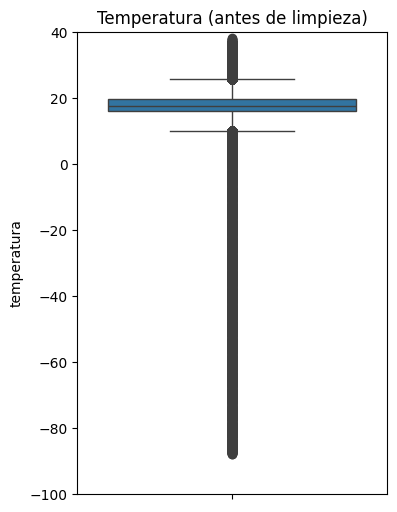

In [19]:
plt.figure(figsize=(4, 6))
sns.boxplot(y=df_clima["temperatura"])
plt.title("Temperatura (antes de limpieza)")

# Ajustar el rango del eje Y para incluir bien los negativos
plt.ylim(-100, 40)  # aquí SI se ven los -88 °C
plt.show()

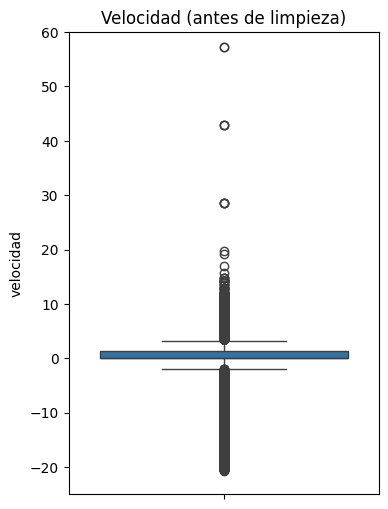

In [20]:
plt.figure(figsize=(4, 6))
sns.boxplot(y=df_clima["velocidad"])
plt.title("Velocidad (antes de limpieza)")
plt.ylim(-25, 60)  # permite ver los valores < 0
plt.show()

NameError: name 'vars_plot' is not defined

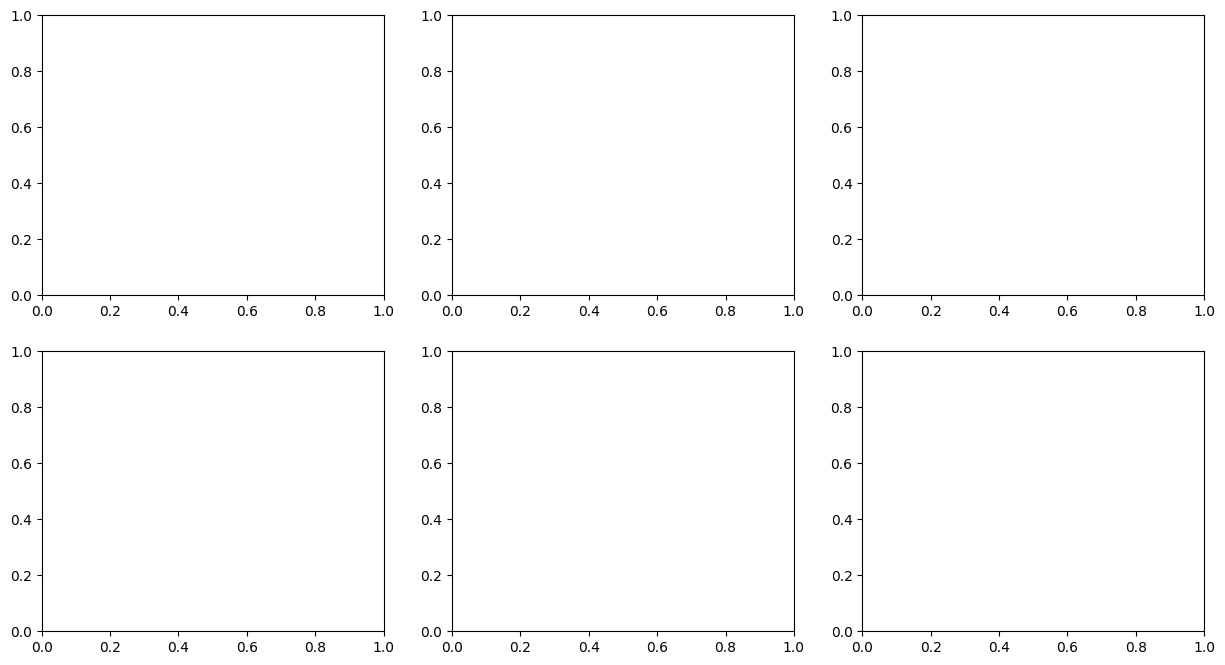

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(vars_plot):
    sns.boxplot(y=df_clima[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [40]:
print(df_clima["temperatura"].info())

<class 'pandas.core.series.Series'>
RangeIndex: 11407292 entries, 0 to 11407291
Series name: temperatura
Non-Null Count     Dtype  
--------------     -----  
10542444 non-null  float64
dtypes: float64(1)
memory usage: 87.0 MB
None


In [39]:
print(df_clima.groupby("estacion_sk")["temperatura"].describe())

                count        mean         std        min    25%    50%    75%  \
estacion_sk                                                                     
19           788108.0   18.615152    5.041847  -9.440000  16.22  17.89  20.89   
20           879575.0  313.784189  664.159765   3.110000  15.72  17.83  21.28   
21           733143.0  123.463207  417.052434   1.000000  17.94  19.56  22.17   
22           827809.0   17.546322    6.022794 -17.780000  15.50  16.94  19.17   
23           799701.0   31.720138  152.933103 -17.780000  16.67  18.22  20.28   
24           776752.0   17.911130   15.514771 -17.780000  15.59  17.48  20.11   
25           879515.0   23.820199  103.527401  11.440000  16.22  17.50  19.17   
26           839394.0   40.232785  204.400233 -18.110000  15.67  17.28  19.11   
27           676103.0   40.638598  212.140679 -88.022962  16.44  17.89  19.89   
28           876406.0   35.643084  175.761522  10.890000  16.39  17.83  19.83   
29           885900.0   17.1

In [54]:
campos_obs = ["temperatura", "velocidad", "direccion", "presion", "humedad", "evapotranspiracion"]

# Función para extraer un campo numérico del texto de observaciones
def extraer_valor(texto, campo):
    if not isinstance(texto, str):
        return np.nan
    patron = rf"{campo}\s*:\s*([-+]?\d*\.?\d+)"
    m = re.search(patron, texto)
    return float(m.group(1)) if m else np.nan

# Para cada campo, creamos una serie con lo extraído y la usamos SOLO donde falta el dato
for campo in campos_obs:
    extra = df_clima["observaciones"].apply(lambda txt: extraer_valor(txt, campo))
    mask = df_clima[campo].isna() & extra.notna()
    df_clima.loc[mask, campo] = extra[mask]

In [55]:
# 1. Definimos rangos físicos razonables
# Estos rangos se basan en guías WMO y en la física básica de cada variable.

# Temperatura (°C) – rango razonable para Manizales
df_clima.loc[(df_clima["temperatura"] < -10) | (df_clima["temperatura"] > 40), "temperatura"] = np.nan

# Velocidad del viento (no puede ser negativa)
df_clima.loc[df_clima["velocidad"] < 0, "velocidad"] = np.nan

# Dirección del viento (0–360 grados)
df_clima.loc[(df_clima["direccion"] < 0) | (df_clima["direccion"] > 360), "direccion"] = np.nan

# Humedad relativa (0–100 %)
df_clima.loc[(df_clima["humedad"] < 0) | (df_clima["humedad"] > 100), "humedad"] = np.nan

# Radiación (no puede ser negativa)
df_clima.loc[df_clima["radiacion"] < 0, "radiacion"] = np.nan

# Presión – aquí solo quitamos 0, que es físicamente imposible
df_clima.loc[df_clima["presion"] <= 0, "presion"] = np.nan

# Evapotranspiración y evapo_real (no negativas)
df_clima.loc[df_clima["evapotranspiracion"] < 0, "evapotranspiracion"] = np.nan
df_clima.loc[df_clima["evapo_real"] < 0, "evapo_real"] = np.nan

In [56]:
print(df_clima.groupby("estacion_sk")["temperatura"].describe())

                count       mean       std        min    25%    50%    75%  \
estacion_sk                                                                  
19           788104.0  18.606097  3.044151  -9.440000  16.22  17.89  20.89   
20           733591.0  17.509088  2.608503   3.110000  15.44  16.94  19.39   
21           690546.0  19.883407  2.688405   1.000000  17.83  19.33  21.61   
22           827781.0  17.531575  2.620431  -3.220000  15.50  16.94  19.17   
23           793679.0  18.524078  2.652371 -10.000000  16.67  18.22  20.22   
24           776453.0  17.792706  3.390165  -9.940000  15.59  17.50  20.11   
25           876547.0  17.797193  2.064621  11.440000  16.22  17.50  19.11   
26           828769.0  17.528245  2.539980 -10.000000  15.67  17.22  19.00   
27           667225.0  18.252295  2.495214  -9.950243  16.39  17.89  19.78   
28           867821.0  18.163199  2.399126  10.890000  16.33  17.78  19.78   
29           885732.0  17.053680  2.834479  -9.940000  14.89  16

In [25]:
df_clima["year"] = df_clima["timestamp"].dt.year
df_clima["month"] = df_clima["timestamp"].dt.month
df_clima["day"] = df_clima["timestamp"].dt.day
df_clima["hour"] = df_clima["timestamp"].dt.hour

EDA numérico y temporal mínimo

In [43]:
print(df_clima[cols_num].describe())

       temperatura_imp   humedad_imp   presion_imp  radiacion_imp
count     1.140729e+07  1.140729e+07  1.140729e+07   1.140729e+07
mean      5.906755e+01  8.387515e+01  5.557172e+02   1.397953e+02
std       2.636988e+02  3.883693e+01  1.560258e+02   2.449237e+02
min      -8.802296e+01  0.000000e+00 -1.676600e+02  -1.699300e+04
25%       1.589000e+01  7.700000e+01  5.912900e+02   0.000000e+00
50%       1.767000e+01  8.500000e+01  5.951800e+02   0.000000e+00
75%       2.003896e+01  9.200000e+01  6.048400e+02   2.230000e+02
max       3.623060e+03  6.368800e+02  1.660772e+03   1.448000e+03


Descriptivos por estación (ej. temperatura)

In [53]:
print(df_clima.groupby("estacion_sk")["temperatura"].describe())

                count       mean       std        min    25%    50%    75%  \
estacion_sk                                                                  
19           788104.0  18.606097  3.044151  -9.440000  16.22  17.89  20.89   
20           733591.0  17.509088  2.608503   3.110000  15.44  16.94  19.39   
21           690546.0  19.883407  2.688405   1.000000  17.83  19.33  21.61   
22           827781.0  17.531575  2.620431  -3.220000  15.50  16.94  19.17   
23           793679.0  18.524078  2.652371 -10.000000  16.67  18.22  20.22   
24           776453.0  17.792706  3.390165  -9.940000  15.59  17.50  20.11   
25           876547.0  17.797193  2.064621  11.440000  16.22  17.50  19.11   
26           828769.0  17.528245  2.539980 -10.000000  15.67  17.22  19.00   
27           667225.0  18.252295  2.495214  -9.950243  16.39  17.89  19.78   
28           867821.0  18.163199  2.399126  10.890000  16.33  17.78  19.78   
29           885732.0  17.053680  2.834479  -9.940000  14.89  16

Correlación entre variables meteorológicas:

In [28]:
corr = df_clima[cols_num].corr()
print(corr)

                    temperatura  velocidad  direccion    caudal   presion  \
temperatura            1.000000   0.174088   0.331873 -0.014100  0.002659   
velocidad              0.174088   1.000000   0.117719 -0.007948  0.086263   
direccion              0.331873   0.117719   1.000000 -0.051322  0.420011   
caudal                -0.014100  -0.007948  -0.051322  1.000000 -0.127387   
presion                0.002659   0.086263   0.420011 -0.127387  1.000000   
humedad               -0.257658   0.183049   0.267418 -0.102764  0.905142   
precipitacion         -0.103823  -0.014358   0.029692 -0.006965  0.050093   
precipitacion_real    -0.006836   0.000733   0.000054  0.001215 -0.000685   
radiacion              0.552522   0.276815   0.394997 -0.018284  0.152192   
evapotranspiracion    -0.087956  -0.010785   0.050727 -0.010755  0.084103   
evapo_real             0.002119   0.001048   0.003539 -0.000282  0.001653   
nivel                 -0.019744  -0.019208  -0.124102  0.545553 -0.309038   

In [ ]:
#df_clima = df_clima.sort_values(["estacion_sk", "timestamp"]).reset_index(drop=True)

#df_clima["temperatura_interp"] = (
#    df_clima.groupby("estacion_sk")["temperatura"]
#            .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
#)

In [45]:
df_clima.head()

,fecha,hora,temperatura,velocidad,direccion,direccion_rosa,caudal,presion,humedad,precipitacion,...,estacion_sk,timestamp,year,month,day,hour,temperatura_imp,humedad_imp,presion_imp,radiacion_imp
0,2012-03-28,01:06:28,15.56,1.79,131.0,X,0.0,610.77098,86.0,0.0,...,19,2012-03-28 01:06:28,2012,3,28,1,15.56,86.0,610.77098,0.0
1,2012-03-28,01:11:28,15.39,1.79,104.0,X,0.0,610.77098,88.0,0.0,...,19,2012-03-28 01:11:28,2012,3,28,1,15.39,88.0,610.77098,0.0
2,2012-03-28,01:16:31,15.39,2.68,96.0,X,0.0,610.31360,88.0,0.0,...,19,2012-03-28 01:16:31,2012,3,28,1,15.39,88.0,610.31360,0.0
3,2012-03-28,01:46:31,15.44,1.79,106.0,X,0.0,610.05950,86.0,0.0,...,19,2012-03-28 01:46:31,2012,3,28,1,15.44,86.0,610.05950,0.0
4,2012-03-28,01:51:35,15.56,0.45,105.0,ESE,0.0,610.06000,86.0,0.0,...,19,2012-03-28 01:51:35,2012,3,28,1,15.56,86.0,610.06000,0.0


Interpretando los datos encontramos que algunos de los datos faltantes en las columnas de datos metereologicos se encuentran en observaciones, dado esto organizaremos los datos en las columndas correspondientes.

“En varias estaciones, algunos sensores registraban las variables meteorológicas únicamente en el campo de texto ‘observaciones’ (por ejemplo, temperatura: 17.11 - presion: 600.89 - humedad: 97). Antes de proceder a la imputación de datos faltantes, se implementó un proceso de extracción de estos valores mediante expresiones regulares, rellenando las columnas numéricas correspondientes (temperatura, presión, humedad, dirección) allí donde estaban vacías pero existía información en ‘observaciones’. Este paso reduce la cantidad de datos aparentemente faltantes y evita imputar valores cuando los datos reales sí están presentes en el archivo original.”

In [ ]:
# ORDEN ERRONEO DE IMPUTACION

#campos_obs = ["temperatura", "velocidad", "direccion", "presion", "humedad", "evapotranspiracion"]

# Función para extraer un campo numérico del texto de observaciones
#def extraer_valor(texto, campo):
#    if not isinstance(texto, str):
#        return np.nan
#    patron = rf"{campo}\s*:\s*([-+]?\d*\.?\d+)"
#    m = re.search(patron, texto)
#    return float(m.group(1)) if m else np.nan

# Para cada campo, creamos una serie con lo extraído y la usamos SOLO donde falta el dato
#for campo in campos_obs:
#    extra = df_clima["observaciones"].apply(lambda txt: extraer_valor(txt, campo))
#    mask = df_clima[campo].isna() & extra.notna()
#    df_clima.loc[mask, campo] = extra[mask]




In [47]:
df_clima.head()

,fecha,hora,temperatura,velocidad,direccion,direccion_rosa,caudal,presion,humedad,precipitacion,...,estacion_sk,timestamp,year,month,day,hour,temperatura_imp,humedad_imp,presion_imp,radiacion_imp
0,2012-03-28,01:06:28,15.56,1.79,131.0,X,0.0,610.77098,86.0,0.0,...,19,2012-03-28 01:06:28,2012,3,28,1,15.56,86.0,610.77098,0.0
1,2012-03-28,01:11:28,15.39,1.79,104.0,X,0.0,610.77098,88.0,0.0,...,19,2012-03-28 01:11:28,2012,3,28,1,15.39,88.0,610.77098,0.0
2,2012-03-28,01:16:31,15.39,2.68,96.0,X,0.0,610.31360,88.0,0.0,...,19,2012-03-28 01:16:31,2012,3,28,1,15.39,88.0,610.31360,0.0
3,2012-03-28,01:46:31,15.44,1.79,106.0,X,0.0,610.05950,86.0,0.0,...,19,2012-03-28 01:46:31,2012,3,28,1,15.44,86.0,610.05950,0.0
4,2012-03-28,01:51:35,15.56,0.45,105.0,ESE,0.0,610.06000,86.0,0.0,...,19,2012-03-28 01:51:35,2012,3,28,1,15.56,86.0,610.06000,0.0


 se emplearon métodos de imputación para reconstruir las series sin eliminar filas. En línea con enfoques como CLIMFILL, se conservaron las columnas originales y se generaron versiones imputadas de las variables clave, usadas en los módulos posteriores de análisis y modelado

In [57]:
df_clima = df_clima.sort_values(["estacion_sk", "timestamp"])

# Temperatura imputada por interpolación temporal
df_clima["temperatura_imp"] = (
    df_clima.groupby("estacion_sk")["temperatura"]
            .transform(lambda s: s.interpolate(method="linear",
                                               limit_direction="both"))
)

# Humedad imputada por interpolación temporal
df_clima["humedad_imp"] = (
    df_clima.groupby("estacion_sk")["humedad"]
            .transform(lambda s: s.interpolate(method="linear",
                                               limit_direction="both"))
)


df_clima["presion_imp"] = (
    df_clima.groupby("estacion_sk")["presion"]
            .transform(lambda s: s.interpolate(method="linear",
                                               limit_direction="both"))
)

df_clima["radiacion_imp"] = (
    df_clima.groupby("estacion_sk")["radiacion"]
            .transform(lambda s: s.interpolate(method="linear",
                                               limit_direction="both"))
)

In [58]:
print(df_clima.groupby("estacion_sk")["temperatura"].describe())

                count       mean       std        min    25%    50%    75%  \
estacion_sk                                                                  
19           788104.0  18.606097  3.044151  -9.440000  16.22  17.89  20.89   
20           733591.0  17.509088  2.608503   3.110000  15.44  16.94  19.39   
21           690546.0  19.883407  2.688405   1.000000  17.83  19.33  21.61   
22           827781.0  17.531575  2.620431  -3.220000  15.50  16.94  19.17   
23           793679.0  18.524078  2.652371 -10.000000  16.67  18.22  20.22   
24           776453.0  17.792706  3.390165  -9.940000  15.59  17.50  20.11   
25           876547.0  17.797193  2.064621  11.440000  16.22  17.50  19.11   
26           828769.0  17.528245  2.539980 -10.000000  15.67  17.22  19.00   
27           667225.0  18.252295  2.495214  -9.950243  16.39  17.89  19.78   
28           867821.0  18.163199  2.399126  10.890000  16.33  17.78  19.78   
29           885732.0  17.053680  2.834479  -9.940000  14.89  16

In [59]:
df_clima.head()

,fecha,hora,temperatura,velocidad,direccion,direccion_rosa,caudal,presion,humedad,precipitacion,...,estacion_sk,timestamp,year,month,day,hour,temperatura_imp,humedad_imp,presion_imp,radiacion_imp
0,2012-03-28,01:06:28,15.56,1.79,131.0,X,0.0,610.77098,86.0,0.0,...,19,2012-03-28 01:06:28,2012,3,28,1,15.56,86.0,610.77098,0.0
1,2012-03-28,01:11:28,15.39,1.79,104.0,X,0.0,610.77098,88.0,0.0,...,19,2012-03-28 01:11:28,2012,3,28,1,15.39,88.0,610.77098,0.0
2,2012-03-28,01:16:31,15.39,2.68,96.0,X,0.0,610.31360,88.0,0.0,...,19,2012-03-28 01:16:31,2012,3,28,1,15.39,88.0,610.31360,0.0
3,2012-03-28,01:46:31,15.44,1.79,106.0,X,0.0,610.05950,86.0,0.0,...,19,2012-03-28 01:46:31,2012,3,28,1,15.44,86.0,610.05950,0.0
4,2012-03-28,01:51:35,15.56,0.45,105.0,ESE,0.0,610.06000,86.0,0.0,...,19,2012-03-28 01:51:35,2012,3,28,1,15.56,86.0,610.06000,0.0


In [60]:
cols_num = [
    "temperatura_imp","humedad_imp","presion_imp","radiacion_imp"
]

faltantes_global = df_clima[cols_num].isna().mean().sort_values(ascending=False)
print(faltantes_global)

presion_imp        0.067175
temperatura_imp    0.000000
humedad_imp        0.000000
radiacion_imp      0.000000
dtype: float64


In [61]:
print(df_clima.groupby("estacion_sk")["temperatura_imp"].describe())

                count       mean       std        min    25%        50%  \
estacion_sk                                                               
19           903106.0  18.944274  3.134468  -9.440000  16.39  18.390000   
20           903587.0  17.474764  2.536267   3.110000  15.61  16.861099   
21           889290.0  19.991287  2.674506   1.000000  18.00  19.560000   
22           901925.0  17.566176  2.627742  -3.220000  15.56  17.000000   
23           865767.0  18.564811  2.669253 -10.000000  16.67  18.280000   
24           903856.0  17.651009  3.368853  -9.940000  15.50  17.500000   
25           898890.0  17.800611  2.066101  11.440000  16.22  17.500000   
26           899250.0  17.430019  2.888823 -10.000000  15.67  17.170000   
27           767428.0  18.278898  2.734766  -9.950243  16.44  17.957619   
28           903107.0  18.171575  2.388298  10.890000  16.39  17.830000   
29           903391.0  17.072726  2.875136  -9.940000  14.89  16.390000   
30           766290.0  17

In [64]:
print(df_clima.groupby("estacion_sk")["humedad_imp"].describe())

                count       mean        std   min        25%        50%   75%  \
estacion_sk                                                                     
19           903106.0  78.964089  11.257724   0.0  72.000000  81.000000  88.0   
20           903587.0  88.520679   9.461290  26.0  84.000000  92.000000  95.0   
21           889290.0  83.641117   9.369460   0.0  79.221971  84.704723  90.0   
22           901925.0  81.243745  11.492770   0.0  75.000000  83.000000  90.0   
23           865767.0  88.063547   9.871371   0.0  83.209577  91.000000  95.0   
24           903856.0  83.918626  10.066178   0.0  79.000000  85.000000  91.0   
25           898890.0  83.413321   8.369475  33.0  79.000000  85.000000  89.0   
26           899250.0  84.712873  10.000748   7.0  80.000000  87.000000  92.0   
27           767428.0  87.252303  10.968001   0.0  82.000000  90.000000  95.0   
28           903107.0  80.980534   6.242405  34.0  78.000000  82.000000  85.0   
29           903391.0  87.53

In [62]:
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407292 entries, 0 to 11407291
Data columns (total 31 columns):
 #   Column              Dtype         
---  ------              -----         
 0   fecha               object        
 1   hora                object        
 2   temperatura         float64       
 3   velocidad           float64       
 4   direccion           float64       
 5   direccion_rosa      object        
 6   caudal              float64       
 7   presion             float64       
 8   humedad             float64       
 9   precipitacion       float64       
 10  precipitacion_real  float64       
 11  radiacion           float64       
 12  evapotranspiracion  float64       
 13  evapo_real          float64       
 14  nivel               float64       
 15  estado_Alarma       object        
 16  puerta_Abierta      bool          
 17  bateria_Baja        bool          
 18  solar_energia       bool          
 19  sensor_Activo       bool          
 20  

In [65]:
# Exportar TODO el dataset (32 columnas) en CSV comprimido
df_clima.to_csv("preprocesado_modulo1.csv.gz", index=False, compression="gzip")

print("✅ Exportado dataset COMPLETO:")
print(f"- Filas: {len(df_clima):,}")
print(f"- Columnas: {len(df_clima.columns)}")
print("- preprocesado_modulo1.csv.gz (~1.5-2GB)")

✅ Exportado dataset COMPLETO:
- Filas: 11,407,292
- Columnas: 31
- preprocesado_modulo1.csv.gz (~1.5-2GB)
